In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [6]:
metadata = pd.read_csv("data/BIOSCAN_metadata_spathi.csv", sep=",")

/var/folders/k4/f_bpyr193w1dyd_9bdnnr3pc0000gn/T/ipykernel_6132/3282351175.py:1: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv("data/BIOSCAN_metadata_spathi.csv", sep=",")


# Initial exploration
### Unique values of original image size and their relationship to scale source

In [47]:
pd.DataFrame(metadata.original_image_size.value_counts())

,count
original_image_size,
"1024,768",5149703
"2880,2160",622
"1024,769",172
"2160,1620",53
"1024,770",42
...,...
"3728,2797",1
"7445,5583",1
"1024,819",1


Most of the images have an original image size of 1024, 768 (== BIOSCAN rescaled size), but there are some that have different sizes. The most common other size is 2880, 2160 which corresponds to the 'raw' size of Keyence images (before any rescaling). The other sizes are much less common and a set of them are only variant of the 1024, 768 size (e.g. 1024, 769).

In [48]:
pd.DataFrame(metadata[["original_image_size", "scale_source"]].value_counts()).sort_values(by=["count", "scale_source", "original_image_size"], ascending=[False, True, True])#.to_csv("info/image_sizes_per_scale_source.txt", sep="\t")

count
original_image_size scale_source                
1024,768            Keyence fixed scale  5148020
                    scalebar pipeline       1683
2880,2160           Keyence fixed scale      620
1024,769            scalebar pipeline        165
2160,1620           Keyence fixed scale       53
...                                          ...
8691,6518           scalebar pipeline          1
9225,6919           scalebar pipeline          1
9301,6976           scalebar pipeline          1
9655,7241           scalebar pipeline          1
9782,7337           scalebar pipeline          1

[154 rows x 1 columns]

Most of the images with the 2880, 2160 size are Keyence images (only 2 of them are from other sources). 2880, 2160 is not the only other size that Keyence images have, same for other sources.

# Sanity check of ratios before computing the rescaling factor

- aspect ratio = height / width -> is not stable across images sizes
- ratio_x = width / 1024 and ratio_y = height / 768 -> these are the values that we will use to compute the rescaling factor, they are variable across images sizes but they are the same between the two (i.e. ratio_x ~ ratio_y for all images)
- To check that ratio_x and ratio_y are the same, we compute the ratio between them and check that it is close to 1 for all images in the column ratio_diff.

In [49]:
image_size = metadata[["processid", "original_image_size", "scale_source", "scale_px_to_mm", "original_insect_pixels", "organism_area_mm2"]].set_index("processid")
image_size["aspect_ratio"] = image_size["original_image_size"].apply(lambda x: float(x.split(",")[0]) / float(x.split(",")[1])).astype(float)
image_size["ratio_x"] = image_size["original_image_size"].apply(lambda x: 2880.0 / float(x.split(",")[0])).astype(float)
image_size["ratio_y"] = image_size["original_image_size"].apply(lambda x: 2160.0 / float(x.split(",")[1])).astype(float)
image_size["ratio_diff"] = image_size["ratio_x"] / image_size["ratio_y"]

In [50]:
display(image_size[["aspect_ratio", "ratio_x", "ratio_y", "ratio_diff"]].describe(include="all"))
display(image_size[(image_size["ratio_x"] != 1) | (image_size["ratio_y"] != 1)][["aspect_ratio", "ratio_x", "ratio_y", "ratio_diff"]].describe(include="all"))
print(f'Number of images with ratio_diff outside 1±0.01: {((image_size["ratio_diff"] > 1.01) | (image_size["ratio_diff"] < 0.99)).sum()}')

,aspect_ratio,ratio_x,ratio_y,ratio_diff
count,5.150850e+06,5.150850e+06,5.150850e+06,5.150850e+06
mean,1.333335e+00,2.812236e+00,2.812240e+00,9.999998e-01
std,1.386095e-03,2.205759e-02,2.225053e-02,1.167936e-03
min,6.489227e-01,2.716212e-01,2.716298e-01,5.859375e-01
25%,1.333333e+00,2.812500e+00,2.812500e+00,1.000000e+00
50%,1.333333e+00,2.812500e+00,2.812500e+00,1.000000e+00
75%,1.333333e+00,2.812500e+00,2.812500e+00,1.000000e+00
max,2.275556e+00,4.492980e+00,4.800000e+00,2.054688e+00


,aspect_ratio,ratio_x,ratio_y,ratio_diff
count,5.150228e+06,5.150228e+06,5.150228e+06,5.150228e+06
mean,1.333335e+00,2.812455e+00,2.812458e+00,9.999998e-01
std,1.386179e-03,9.482141e-03,9.922653e-03,1.168007e-03
min,6.489227e-01,2.716212e-01,2.716298e-01,5.859375e-01
25%,1.333333e+00,2.812500e+00,2.812500e+00,1.000000e+00
50%,1.333333e+00,2.812500e+00,2.812500e+00,1.000000e+00
75%,1.333333e+00,2.812500e+00,2.812500e+00,1.000000e+00
max,2.275556e+00,4.492980e+00,4.800000e+00,2.054688e+00


Number of images with ratio_diff outside 1±0.01: 116


- First table include all images (and is dominated by the images with original image size of 1024, 768), second table only includes images where ratio_x or ratio_y is different from 1 (i.e. images that are not 1024, 768). 
- We can see that the aspect ratio is not stable across images sizes (it ranges from 0.65 to 2.28), the ratio_x and ratio_y are even more variable across images sizes (they range from 0.58 to 10.35) but they are the same for almost all images. The difference between them is less than 1% for all images except 116 images (for which the ratio can be up to 1.71 and as low as 0.49) -> not perfect but good enough given the approximation already involved in the organism area estimation

# Compute updated scale and organism size

For Keyence images we know that the initial raw scale is 2.95 um/px in both dimensions, so we can directly compute the new scale by multiplying this value by the average of ratio_x and ratio_y (since they are very similar). For the other images we keep the previously computed scale_px_to_mm value (this value was extracted from the 'original' images with the scale bar recognition pipeline). We then compute the new organism area in mm2 using the new scale and the original insect pixels.

In [51]:
image_size["new_scale"] = image_size.apply(
	lambda x: 
    	2.95e-3 * (x["ratio_x"] + x["ratio_y"]) / 2
		if x["scale_source"] == "Keyence fixed scale" 
		else x["scale_px_to_mm"],
	axis=1,
)
image_size["new_scale"] = image_size["new_scale"] 
# In scientific notation
image_size["new_scale"] = image_size["new_scale"].apply(lambda x: "{:.7e}".format(x))
image_size["new_organism_area_mm2"] = image_size["new_scale"].astype(float) ** 2 * image_size["original_insect_pixels"]
image_size

,original_image_size,scale_source,scale_px_to_mm,original_insect_pixels,organism_area_mm2,aspect_ratio,ratio_x,ratio_y,ratio_diff,new_scale,new_organism_area_mm2
processid,,,,,,,,,,,
AACTA1000-20,"1024,768",Keyence fixed scale,0.000003,7373.0,6.416353e-08,1.333333,2.8125,2.8125,1.0,8.2968750e-03,0.507544
AACTA1001-20,"1024,768",Keyence fixed scale,0.000003,10893.0,9.479633e-08,1.333333,2.8125,2.8125,1.0,8.2968750e-03,0.749854
AACTA1002-20,"1024,768",Keyence fixed scale,0.000003,15709.0,1.367076e-07,1.333333,2.8125,2.8125,1.0,8.2968750e-03,1.081378
AACTA1003-20,"1024,768",Keyence fixed scale,0.000003,25669.0,2.233845e-07,1.333333,2.8125,2.8125,1.0,8.2968750e-03,1.767006
AACTA1004-20,"1024,768",Keyence fixed scale,0.000003,11220.0,9.764205e-08,1.333333,2.8125,2.8125,1.0,8.2968750e-03,0.772364
...,...,...,...,...,...,...,...,...,...,...,...
YGEN995-22,"1024,768",Keyence fixed scale,0.000003,18683.0,1.625888e-07,1.333333,2.8125,2.8125,1.0,8.2968750e-03,1.286103
YGEN996-22,"1024,768",Keyence fixed scale,0.000003,23024.0,2.003664e-07,1.333333,2.8125,2.8125,1.0,8.2968750e-03,1.584929
YGEN997-22,"1024,768",Keyence fixed scale,0.000003,15881.0,1.382044e-07,1.333333,2.8125,2.8125,1.0,8.2968750e-03,1.093218


# Results exploration - Organism size distribution

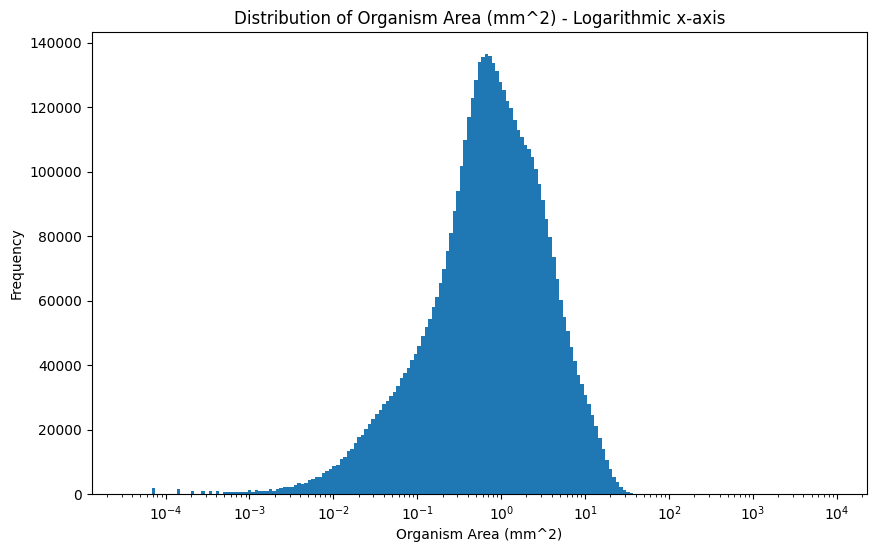

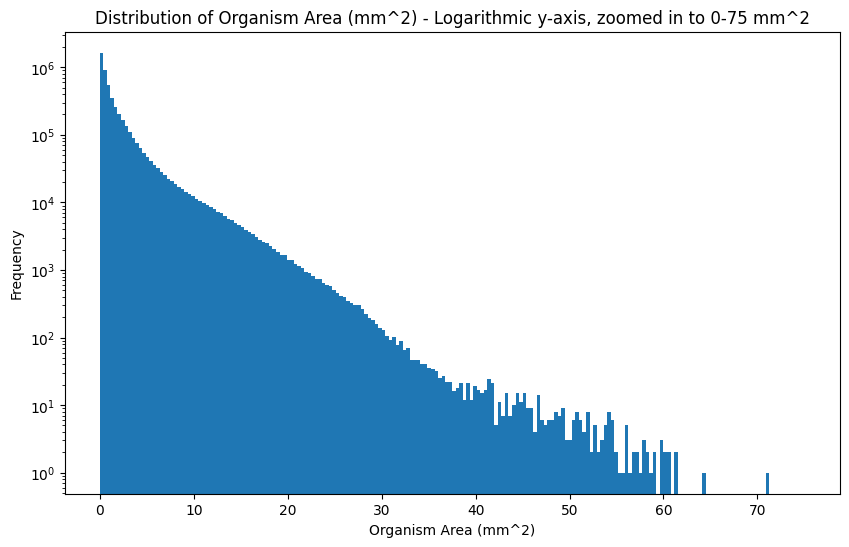

In [52]:
plt.figure(figsize=(10, 6))
# Logarithmic scale for both axes
bins = np.logspace(
    np.log10(image_size["new_organism_area_mm2"].replace(0, np.nan).dropna().min()),
    np.log10(image_size["new_organism_area_mm2"].max()),
    200,
)
image_size.new_organism_area_mm2.plot.hist(bins=bins)
plt.xscale("log")
plt.xlabel("Organism Area (mm^2)")
plt.title("Distribution of Organism Area (mm^2) - Logarithmic x-axis")
plt.show()
plt.figure(figsize=(10, 6))
image_size.new_organism_area_mm2.plot.hist(range=(0, 75), bins=200, log=True)
plt.xlabel("Organism Area (mm^2)")
plt.title("Distribution of Organism Area (mm^2) - Logarithmic y-axis, zoomed in to 0-75 mm^2")
plt.show()


### Largest organism size (verified with image on BIOSCAN-browser)

In [53]:
image_size.loc[image_size.new_organism_area_mm2.idxmax()]

original_image_size                1024,768
scale_source              scalebar pipeline
scale_px_to_mm                     0.208333
original_insect_pixels             199863.0
organism_area_mm2               8674.609375
aspect_ratio                       1.333333
ratio_x                              2.8125
ratio_y                              2.8125
ratio_diff                              1.0
new_scale                     2.0833333e-01
new_organism_area_mm2           8674.609097
Name: GGIO168-22, dtype: object

This process id corresponds to this image for reference: https://spathi.cmpt.sfu.ca/data/bioscan/bioscan5m/images/original_256/train/7/GGIO168-22.jpg

In [54]:
# Randomly sample 1 image from the dataset
image_size.iloc[784]

original_image_size                  1024,768
scale_source              Keyence fixed scale
scale_px_to_mm                       0.000003
original_insect_pixels                23383.0
organism_area_mm2                         0.0
aspect_ratio                         1.333333
ratio_x                                2.8125
ratio_y                                2.8125
ratio_diff                                1.0
new_scale                       8.2968750e-03
new_organism_area_mm2                1.609642
Name: AACTA229-20, dtype: object

This process id corresponds to this image for reference: https://spathi.cmpt.sfu.ca/data/bioscan/bioscan5m/images/original_256/pretrain/16/AACTA229-20.jpg

# Save results

In [55]:
to_save = image_size[["scale_source", "new_scale", "new_organism_area_mm2"]].rename(columns={"new_scale": "scale_px_to_mm", "new_organism_area_mm2": "organism_area_mm2"}).reset_index()
to_save.to_csv("data/BIOSCAN_5M_scale_data_updated.csv", index=False)